# derived_8.4-feature-selection-2.0

This report documents the isolated direct feature search for the 2023–2025 target period. It reads only tracked experiment artifacts, generates every table and figure below, and keeps the existing feature-selection lines unchanged.


## Reproducible setup

The notebook resolves paths from the repository root and uses the local 2.0 artifacts. Run `run_search.py` first; this notebook intentionally does not rerun a long search while rendering the report.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


def find_project_root() -> Path:
    for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Could not locate the MDR project root.")


PROJECT_ROOT = find_project_root()
EXP_DIR = PROJECT_ROOT / "notebooks/experiment/derived_8.4-feature-selection-2.0"
if str(EXP_DIR) not in sys.path:
    sys.path.insert(0, str(EXP_DIR))
from fs20.reporting import build_exact_leaderboard

ARTIFACT_DIR = EXP_DIR / "artifacts"
FIGURE_DIR = EXP_DIR / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Artifact directory: {ARTIFACT_DIR}")


Project root: /scratch/user/u.rp352032/MDR-Project
Artifact directory: /scratch/user/u.rp352032/MDR-Project/notebooks/experiment/derived_8.4-feature-selection-2.0/artifacts


## Load generated search artifacts

The raw audit and search files are the source of all reported numbers. Failing early when the bounded search has not completed prevents a partial or manually assembled report.

In [2]:
summary_path = ARTIFACT_DIR / "search_summary.json"
audit_path = ARTIFACT_DIR / "audit/collapse_audit.csv"
results_path = ARTIFACT_DIR / "search_results.csv"
aliases_path = ARTIFACT_DIR / "candidate_aliases.csv"
delta_grid_path = ARTIFACT_DIR / "delta_grid.csv"
pool_path = ARTIFACT_DIR / "candidate_pool.csv"

required_paths = [
    summary_path,
    audit_path,
    results_path,
    aliases_path,
    delta_grid_path,
    pool_path,
]
missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError(
        "Run the corrected full search before executing this report notebook. Missing: "
        + ", ".join(str(path.relative_to(PROJECT_ROOT)) for path in missing_paths)
    )

summary = json.loads(summary_path.read_text(encoding="utf-8"))
if summary.get("status") != "complete":
    raise RuntimeError(
        "The search is incomplete, so it has no reportable winner: "
        + str(summary.get("incomplete_reason", "unknown reason"))
    )
if summary.get("delta_grid", {}).get("status") != "complete":
    raise RuntimeError("The required 0/5/10 add-only delta grid is incomplete.")

audit_df = pd.read_csv(audit_path)
results_df = pd.read_csv(results_path)
aliases_df = pd.read_csv(aliases_path)
delta_grid_df = pd.read_csv(delta_grid_path)
pool_df = pd.read_csv(pool_path)
expected_delta_rows = 9
if len(delta_grid_df) != expected_delta_rows or not delta_grid_df["evaluation_status"].isin(
    ["fit", "reused"]
).all():
    raise RuntimeError("delta_grid.csv does not contain nine completed 0/5/10 evaluations.")
print(f"Audit rows: {len(audit_df)}")
print(f"Candidate fits: {len(results_df)}")
print(f"Candidate aliases: {len(aliases_df)}")
print(f"Completed delta-grid rows: {len(delta_grid_df)}")
print(f"Candidate-pool rows: {len(pool_df)}")


Audit rows: 35
Candidate fits: 1039
Candidate aliases: 44
Completed delta-grid rows: 9
Candidate-pool rows: 96


## Collapse audit: where the selector loses candidates

This table follows each route from the MI pool through ElasticNet and stability selection. It separates an MI bottleneck from a sparse ElasticNet/stability bottleneck and shows whether the repaired fallback can recover candidates that the historical fallback could not see.

=== COLLAPSE AUDIT ===
| route                 | cluster   | profile              |   n_train |   mi_features |   candidate_features |   elasticnet_nonzero |   stability_features |   repaired_features |   alpha |   l1_ratio | collapse_status   |
|:----------------------|:----------|:---------------------|----------:|--------------:|---------------------:|---------------------:|---------------------:|--------------------:|--------:|-----------:|:------------------|
| Clustering_Dynamic_k2 | 0         | legacy_forced_bypass |      4339 |           300 |                  381 |                    2 |                    2 |                   2 |  0.0296 |     1.0000 | hard_collapsed    |
| Clustering_Dynamic_k2 | 0         | mi120                |      4339 |           120 |                  120 |                   47 |                   38 |                  38 |  0.0078 |     0.1000 | truncated         |
| Clustering_Dynamic_k2 | 0         | mi300                |      4339 |           30

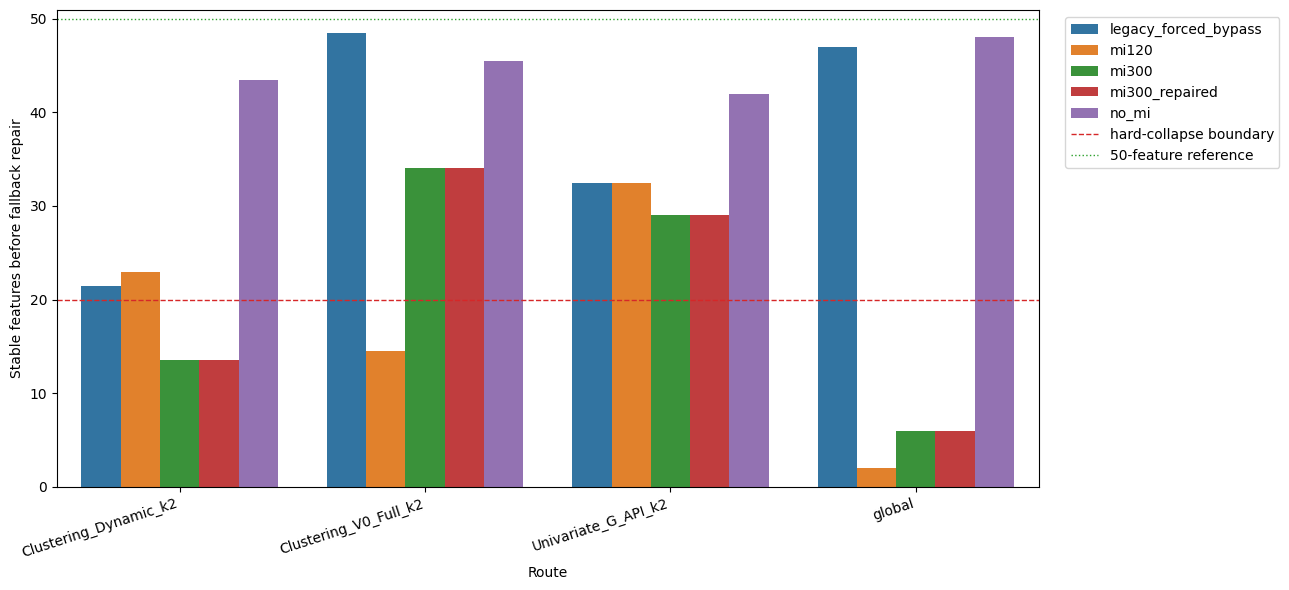

In [3]:
audit_columns = [
    "route", "cluster", "profile", "n_train", "mi_features", "candidate_features",
    "elasticnet_nonzero", "stability_features", "repaired_features", "alpha",
    "l1_ratio", "collapse_status",
]
audit_table = audit_df.loc[:, audit_columns].sort_values(["route", "cluster", "profile"])
print("=== COLLAPSE AUDIT ===")
print(audit_table.to_markdown(index=False, floatfmt=".4f"))

mi300_columns = [
    "route", "cluster", "n_train", "mi_features", "elasticnet_nonzero",
    "stability_features", "repaired_features", "alpha", "l1_ratio", "collapse_status",
]
mi300_audit = audit_df.loc[audit_df["profile"] == "mi300", mi300_columns].copy()
mi300_audit = mi300_audit.rename(
    columns={"repaired_features": "historical_fallback_features"}
)
repaired_fallback = audit_df.loc[
    audit_df["profile"] == "mi300_repaired", ["route", "cluster", "repaired_features"]
].rename(columns={"repaired_features": "repaired_fallback_features"})
audit_highlights = mi300_audit.merge(
    repaired_fallback,
    on=["route", "cluster"],
    how="left",
).sort_values(["route", "cluster"])
print("=== COLLAPSE AUDIT HIGHLIGHTS: MI-300 → ELASTICNET → STABILITY ===")
print(audit_highlights.to_markdown(index=False, floatfmt=".4f"))

plt.figure(figsize=(13, 6))
sns.barplot(
    data=audit_df,
    x="route",
    y="stability_features",
    hue="profile",
    errorbar=None,
)
plt.axhline(20, color="tab:red", linestyle="--", linewidth=1, label="hard-collapse boundary")
plt.axhline(50, color="tab:green", linestyle=":", linewidth=1, label="50-feature reference")
plt.ylabel("Stable features before fallback repair")
plt.xlabel("Route")
plt.xticks(rotation=18, ha="right")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "collapse_funnel_by_route.png", dpi=160)
plt.show()


## Direct target-period leaderboard

Exact fits use the same V0-full K=2 routing and SOTA 1.5 XGBoost parameters as the current benchmark. Proxy fits only prioritize local-search proposals; the leaderboard ranks literal feature configurations by unweighted pooled 2023–2025 R² and consolidates bookkeeping aliases that evaluate the same global and cluster feature lists.


=== EQUIVALENT EXACT-EVALUATION ALIASES ===
| candidate_id                                | equivalent_evaluations                                                                   |   alias_count |
|:--------------------------------------------|:-----------------------------------------------------------------------------------------|--------------:|
| round_06_drop_V_rollrng_F_NDVI_kobs30_exact | round_06_drop_V_rollrng_F_NDVI_kobs30_exact; global_backbone_for_deltas; delta_c0_0_c1_0 |             3 |
| baseline_v0_calibration                     | baseline_v0_calibration; seed_v0; seed_legacy_8_2_forced_bypass                          |             3 |
=== EXACT 2023–2025 LEADERBOARD (UNIQUE FEATURE CONFIGURATIONS) ===
| candidate_id                                                                    |   pooled_r2 |   pooled_rmse |   global_feature_count |   cluster_0_feature_count |   cluster_1_feature_count |   year_2023_r2 |   year_2024_r2 |   year_2025_r2 | equivalent_evaluations

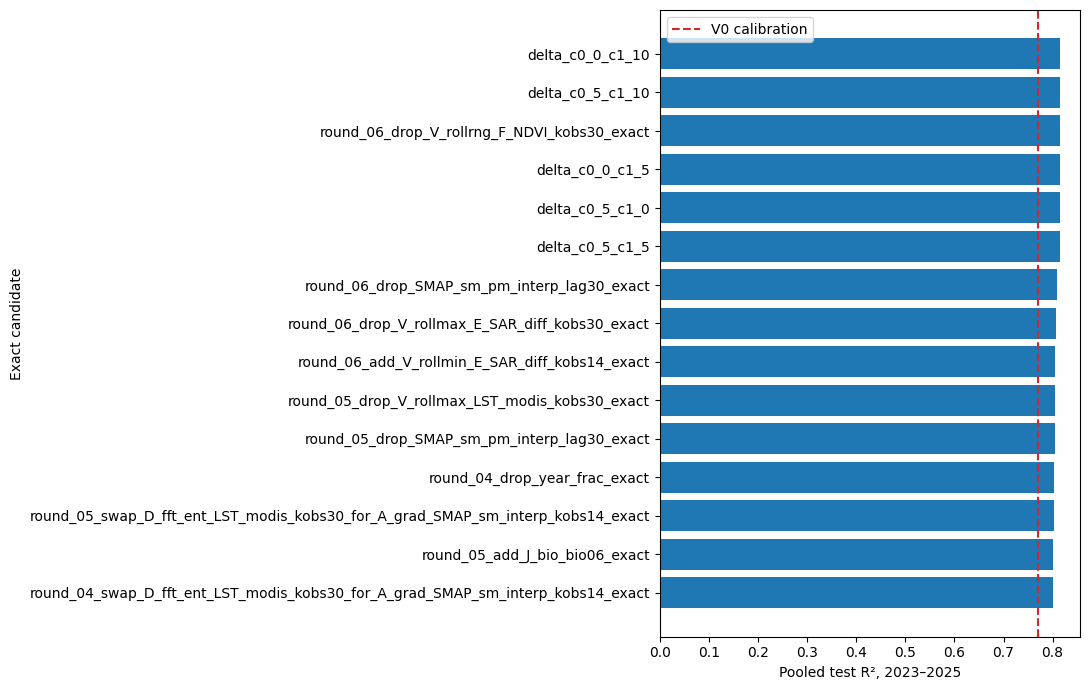

In [4]:
exact_report = build_exact_leaderboard(
    results_df,
    aliases_df,
    summary["winner"]["candidate_id"],
)
leaderboard = exact_report.leaderboard
alias_groups = exact_report.alias_groups
winner_aliases = "; ".join(exact_report.winner_aliases)

print("=== EQUIVALENT EXACT-EVALUATION ALIASES ===")
print(alias_groups.to_markdown(index=False))

leaderboard_columns = [
    "candidate_id", "pooled_r2", "pooled_rmse", "global_feature_count",
    "cluster_0_feature_count", "cluster_1_feature_count", "year_2023_r2",
    "year_2024_r2", "year_2025_r2", "equivalent_evaluations",
]
leaderboard_display = leaderboard.loc[:, leaderboard_columns]
print("=== EXACT 2023–2025 LEADERBOARD (UNIQUE FEATURE CONFIGURATIONS) ===")
print(leaderboard_display.head(20).to_markdown(index=False, floatfmt=".4f"))

plot_rows = leaderboard.head(15).sort_values("pooled_r2")
plt.figure(figsize=(11, 7))
plt.barh(plot_rows["candidate_id"], plot_rows["pooled_r2"], color="tab:blue")
plt.axvline(summary["baseline"]["pooled_r2"], color="tab:red", linestyle="--", label="V0 calibration")
plt.xlabel("Pooled test R², 2023–2025")
plt.ylabel("Exact candidate")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "exact_candidate_leaderboard.png", dpi=160)
plt.show()


## Candidate-pool evidence

The wrapper search combines MI-300 retention, historical seed transferability, all-feature gain, and target-period residual association. This view makes the direct candidate universe inspectable instead of hiding it behind a selector hash or registry.

=== TOP CANDIDATE-POOL FEATURES ===
| feature                         |   support |   consensus_rank |   mi_rank |   seed_frequency |   gain_rank |   residual_rank |   gain |   residual_association |
|:--------------------------------|----------:|-----------------:|----------:|-----------------:|------------:|----------------:|-------:|-----------------------:|
| V_rollmax_F_NDVI_kobs30         |         4 |          34.0000 |   11.0000 |                9 |          25 |              86 | 0.0063 |                 0.1053 |
| V_rollrng_F_NDVI_kobs30         |         4 |          50.2500 |  136.0000 |                8 |          28 |              15 | 0.0055 |                 0.2113 |
| SMAP_sm_pm_interp_rollrange30   |         4 |          66.2500 |  123.0000 |                9 |          75 |              55 | 0.0017 |                 0.1462 |
| SMAP_x_year                     |         4 |          91.5000 |  238.0000 |               12 |          47 |              77 | 0.0026 |      

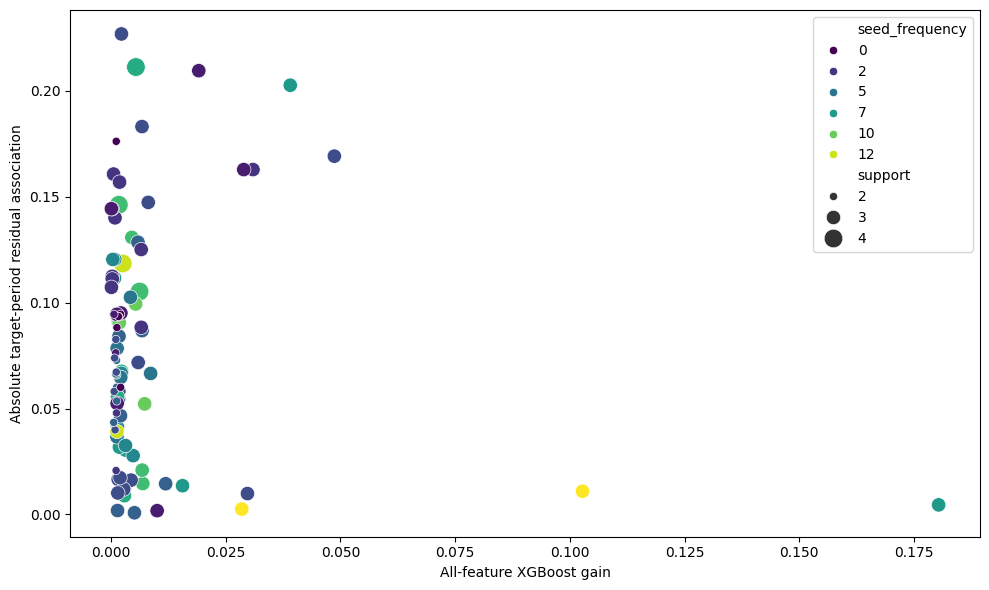

In [5]:
print("=== TOP CANDIDATE-POOL FEATURES ===")
print(pool_df.head(30).to_markdown(index=False, floatfmt=".4f"))

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=pool_df,
    x="gain",
    y="residual_association",
    size="support",
    hue="seed_frequency",
    sizes=(35, 180),
    palette="viridis",
)
plt.xlabel("All-feature XGBoost gain")
plt.ylabel("Absolute target-period residual association")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "candidate_pool_evidence.png", dpi=160)
plt.show()

## Shared backbone and bounded specialist additions

The final architecture keeps one transferable global backbone for both V0 clusters. Specialists can only add zero, five, or ten ranked features, so a sparse cluster selector cannot erase the information that makes the global model strong.

=== FINAL FEATURE CONTRACT ===
| role               | feature                         |
|:-------------------|:--------------------------------|
| global             | precip_mm                       |
| global             | s2_b4                           |
| global             | s2_b8                           |
| global             | SMAP_sm_pm_interp               |
| global             | D_sin_DOY                       |
| global             | D_cos_DOY                       |
| global             | E_SAR_ratio                     |
| global             | G_API                           |
| global             | G_DSLR                          |
| global             | G_rain_sum_3d                   |
| global             | G_rain_sum_7d                   |
| global             | SMAP_sm_pm_interp_lag7          |
| global             | SMAP_sm_pm_interp_lag30         |
| global             | SMAP_sm_pm_interp_rollrange7    |
| global             | SMAP_sm_pm_interp_rollmean30    |


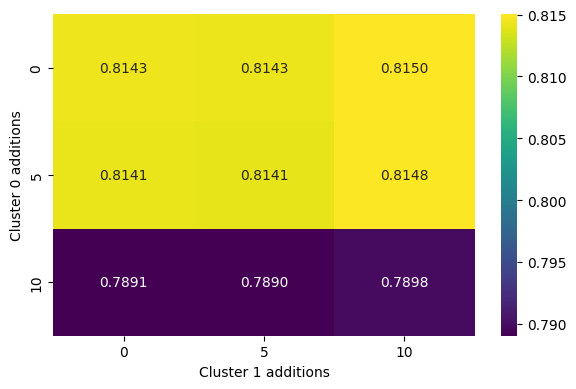

In [6]:
winner = summary["winner"]
baseline = summary["baseline"]
winner_features = pd.DataFrame(
    {
        "role": ["global"] * len(summary["global_features"])
        + ["cluster_0_addition"] * len(summary["cluster_additions"].get("0", []))
        + ["cluster_1_addition"] * len(summary["cluster_additions"].get("1", [])),
        "feature": summary["global_features"]
        + summary["cluster_additions"].get("0", [])
        + summary["cluster_additions"].get("1", []),
    }
)
print("=== FINAL FEATURE CONTRACT ===")
print(winner_features.to_markdown(index=False))

print("=== FINAL COMPARISON ===")
comparison = pd.DataFrame(
    [
        {
            "model": "V0 calibration",
            "pooled_r2": baseline["pooled_r2"],
            "pooled_rmse": baseline["pooled_rmse"],
            "year_2023_r2": baseline["year_2023_r2"],
            "year_2024_r2": baseline["year_2024_r2"],
            "year_2025_r2": baseline["year_2025_r2"],
        },
        {
            "model": "2.0 winner",
            "pooled_r2": winner["pooled_r2"],
            "pooled_rmse": winner["pooled_rmse"],
            "year_2023_r2": winner["year_2023_r2"],
            "year_2024_r2": winner["year_2024_r2"],
            "year_2025_r2": winner["year_2025_r2"],
        },
    ]
)
print(comparison.to_markdown(index=False, floatfmt=".4f"))

expected_counts = {0, 5, 10}
if set(delta_grid_df["cluster_0_addition_count"]) != expected_counts or set(
    delta_grid_df["cluster_1_addition_count"]
) != expected_counts:
    raise RuntimeError("The completed delta grid does not cover every 0/5/10 coordinate.")
delta_grid = delta_grid_df.pivot(
    index="cluster_0_addition_count",
    columns="cluster_1_addition_count",
    values="pooled_r2",
).sort_index().sort_index(axis=1)
print("=== ADD-ONLY DELTA GRID ===")
print(delta_grid.to_markdown(floatfmt=".4f"))
plt.figure(figsize=(6, 4))
sns.heatmap(delta_grid, annot=True, fmt=".4f", cmap="viridis")
plt.xlabel("Cluster 1 additions")
plt.ylabel("Cluster 0 additions")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "bounded_delta_grid.png", dpi=160)
plt.show()


## Generated interpretation

The statements below are constructed from the audit and exact-search outputs. They make the selector failure mode, the transferability result, and the final 2023–2025 comparison easy to review without relying on untracked terminal work.

In [7]:
dynamic_rows = audit_df.loc[
    (audit_df["route"] == "Clustering_Dynamic_k2") & (audit_df["profile"] == "mi300")
].sort_values("cluster")
collapse_rows = audit_df.loc[audit_df["collapse_status"] == "hard_collapsed"]

print("### Generated findings")
print(
    f"- V0 calibration: R²={baseline['pooled_r2']:.4f}, RMSE={baseline['pooled_rmse']:.4f}."
)
print(
    f"- 2.0 winner: R²={winner['pooled_r2']:.4f}, RMSE={winner['pooled_rmse']:.4f}, "
    f"delta R²={winner['pooled_r2'] - baseline['pooled_r2']:+.4f}."
)
print(
    "- Dynamic-route MI-300 audit: "
    + "; ".join(
        f"cluster {row.cluster} had {row.n_train:.0f} train rows, {row.mi_features:.0f} MI candidates, "
        f"{row.elasticnet_nonzero:.0f} ElasticNet nonzero features, and {row.stability_features:.0f} stable features"
        for row in dynamic_rows.itertuples()
    )
    + "."
)
print(
    f"- Hard collapses recorded: {len(collapse_rows)}. The audit records whether they occur before or after MI, "
    "so small specialist lists are not attributed to sample count alone."
)
if len(exact_report.winner_aliases) > 1:
    print(
        "- Equivalent exact-evaluation aliases for the winner: "
        + winner_aliases
        + ". They share the identical global and cluster feature lists, so the report ranks them once."
    )
else:
    print(
        "- Exact-evaluation aliases for the winner: "
        + winner_aliases
        + ". It is a unique configuration with no duplicate fit."
    )
print(
    "- Final specialists are add-only deltas on the shared backbone; no independently selected cluster list can replace it."
)


### Generated findings
- V0 calibration: R²=0.7703, RMSE=0.0488.
- 2.0 winner: R²=0.8150, RMSE=0.0438, delta R²=+0.0447.
- Dynamic-route MI-300 audit: cluster 0 had 4339 train rows, 300 MI candidates, 2 ElasticNet nonzero features, and 2 stable features; cluster 1 had 5464 train rows, 300 MI candidates, 25 ElasticNet nonzero features, and 25 stable features.
- Hard collapses recorded: 11. The audit records whether they occur before or after MI, so small specialist lists are not attributed to sample count alone.
- Exact-evaluation aliases for the winner: delta_c0_0_c1_10. It is a unique configuration with no duplicate fit.
- Final specialists are add-only deltas on the shared backbone; no independently selected cluster list can replace it.
